In [1]:
import sys
print(sys.version)

3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 16.0.0 (clang-1600.0.26.6)]


## Setup

In [2]:
%matplotlib inline

import sys
sys.path.insert(0, "..")  # Add parent directory to path for src imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import itertools

from src import dataset, PLOTS_DIR, DATA_DIR, ensure_dirs_exist
from src.rff import RandomFourierFeatures
from src.backtest import Backtest
from src.backtest_nn import BacktestNN
from src.config import (
    DEFAULT_TRAIN_WINDOW,
    GAMMA_VALUES,
    Z_VALUES_RANGE,
    STANDARDIZATION_BURN_IN,
    METRICS_CACHE_FILE,
)

from joblib import Parallel, delayed

# Ensure output directories exist
ensure_dirs_exist()

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

## 1. Data Loading

We use the **Welch-Goyal (2008) dataset** of monthly equity premium predictors, which is the standard benchmark dataset for return prediction research.

### Features (14 predictors)

| Feature | Description |
|---------|-------------|
| `b/m` | Book-to-market ratio |
| `dp` | Dividend-price ratio (log) |
| `dy` | Dividend yield (log) |
| `ep` | Earnings-price ratio (log) |
| `de` | Dividend payout ratio (log) |
| `tms` | Term spread (long-term yield - T-bill) |
| `dfy` | Default yield spread (BAA - AAA) |
| `dfr` | Default return spread |
| `infl` | Inflation |
| `ltr` | Long-term return |
| `lty` | Long-term yield |
| `ntis` | Net equity expansion |
| `svar` | Stock variance |
| `tbl` | Treasury bill rate |

### Additional Data
- **NBER recession dates** for visualization of market timing performance

In [3]:
# Load data using the dataset module
COLUMNS = dataset.PREDICTOR_COLUMNS[:-1]  # Exclude 'returns' from features
nber = dataset.load_nber()
data, returns = dataset.load_data()

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFeatures ({len(COLUMNS)}): {COLUMNS}")

Data shape: (1141, 15)
Date range: 1926-12-01 00:00:00 to 2021-12-01 00:00:00

Features (14): ['b/m', 'de', 'dfr', 'dfy', 'dp', 'dy', 'ep', 'infl', 'ltr', 'lty', 'ntis', 'svar', 'tbl', 'tms']


## 2. Data Standardization

From the paper:

> We volatility standardize returns and predictors using backward-looking standard deviations that preserve the out-of-sample nature of our forecasts. 

> Returns are standardized by their trailing 12-month return standard deviation (to capture their comparatively fast-moving conditional volatility), while predictors are standardized using an expanding window historical standard deviation (given the much higher persistence of most predictors). 

> We require 36 months of data to ensure that we have enough stability in our initial predictor standardization, so the final sample that we bring to our analysis begins in 1930.

In [4]:
# Standardize predictors using expanding window
for col in COLUMNS:
    data[col] = (data[col] - data[col].expanding(STANDARDIZATION_BURN_IN).mean()) / data[col].expanding(STANDARDIZATION_BURN_IN).std()

# Standardize returns by trailing 12-month volatility
returns_std = returns.rolling(12).std()
returns = returns / returns_std

# Drop first 36 months (burn-in period for standardization)
data = data[STANDARDIZATION_BURN_IN:]
returns = returns[STANDARDIZATION_BURN_IN:]

print(f"Final data shape: {data.shape}")
print(f"Final date range: {data.index.min()} to {data.index.max()}")

Final data shape: (1105, 15)
Final date range: 1929-12-01 00:00:00 to 2021-12-01 00:00:00


In [5]:
data.head()

,b/m,de,dfr,dfy,dp,dy,ep,infl,ltr,lty,ntis,svar,tbl,tms,returns
yyyymm,,,,,,,,,,,,,,,
1929-12-01,-0.111352,-0.712900,2.190619,1.941029,0.615534,0.677822,0.803596,-0.784866,-0.997059,-0.069846,2.360930,0.589444,-1.084280,1.267152,0.025335
1930-01-01,-0.429277,-0.064064,0.873898,1.702201,0.239661,0.521007,0.246324,-0.773431,-0.725579,0.310573,1.945573,-0.263218,-0.571988,0.769990,0.062471
1930-02-01,-0.485541,0.618603,-0.481118,1.242864,0.109786,0.150365,-0.089895,-0.762917,0.759541,-0.133052,1.963163,-0.231310,-0.603514,0.673880,0.021501
1930-03-01,-0.355506,1.282732,0.404217,0.612517,-0.371400,0.022082,-0.756148,-0.753248,0.380861,-0.353684,1.548037,-0.250070,-1.150463,1.252310,0.079897
1930-04-01,-0.241019,1.893425,0.751539,0.534644,-0.300041,-0.453440,-0.903459,1.089104,-0.425167,-0.180288,1.127514,-0.203974,-1.051673,1.182653,-0.009547


In [6]:
TRAIN_WINDOW = DEFAULT_TRAIN_WINDOW  # Number of observations in training window (T)
gammas = GAMMA_VALUES  # RFF bandwidth parameters

In [13]:
nn_results = []
TRAIN_WINDOWs = [12, 36, 60]  # Experiment with different training window sizes
nn_layers = [1,2,4,8]  # Experiment with different numbers of hidden layers
dropout_rates = [0.1, 0.25, 0.5, 1]  # Experiment with different dropout rates
for dropout in dropout_rates:
    for n in nn_layers:
        for T in TRAIN_WINDOWs:
            for hidden in [32, 64, 128]:
                bt_nn = BacktestNN(
                    d_in=len(COLUMNS),
                    hidden_dims=hidden,
                    T=T,          # rolling window
                    epochs=100,              # adjust as needed
                    batch_size=32,
                    lr=1e-3,
                    n_hidden_layers=n,
                    dropout=dropout,  # Add dropout for regularization
                )
                print(f"Running BacktestNN with hidden_dims={hidden}, dropout={dropout}..., train_window={T}, num_hidden_layers={n}...")
                bt_nn.predict(data[COLUMNS], returns.shift(-1))
                perf = bt_nn.calc_performance()
                perf["hidden_dims"] = hidden
                perf["train_window"] = T
                perf["num_hidden_layers"] = n
                perf["dropout"] = dropout
                nn_results.append(perf)

nn_results = pd.DataFrame(nn_results)
nn_results

Running BacktestNN with hidden_dims=32, dropout=0.1..., train_window=12, num_hidden_layers=1...
Running BacktestNN with hidden_dims=64, dropout=0.1..., train_window=12, num_hidden_layers=1...
Running BacktestNN with hidden_dims=128, dropout=0.1..., train_window=12, num_hidden_layers=1...
Running BacktestNN with hidden_dims=32, dropout=0.1..., train_window=36, num_hidden_layers=1...
Running BacktestNN with hidden_dims=64, dropout=0.1..., train_window=36, num_hidden_layers=1...
Running BacktestNN with hidden_dims=128, dropout=0.1..., train_window=36, num_hidden_layers=1...
Running BacktestNN with hidden_dims=32, dropout=0.1..., train_window=60, num_hidden_layers=1...
Running BacktestNN with hidden_dims=64, dropout=0.1..., train_window=60, num_hidden_layers=1...
Running BacktestNN with hidden_dims=128, dropout=0.1..., train_window=60, num_hidden_layers=1...
Running BacktestNN with hidden_dims=32, dropout=0.1..., train_window=12, num_hidden_layers=2...
Running BacktestNN with hidden_dims=6

,beta_norm_mean,Market Sharpe Ratio,Expected Return,Volatility,R2,SR,IR,Alpha,Precision,Recall,Accuracy,hidden_dims,train_window,num_hidden_layers,dropout
0,3.588481,0.636151,0.867440,2.276764,-0.205291,0.380997,0.188869,0.035834,0.614344,0.699538,0.560440,32,12,1,0.1
1,5.010432,0.636151,0.631010,2.679072,-0.342391,0.235533,0.062065,0.013856,0.615708,0.676425,0.556777,64,12,1,0.1
2,7.027016,0.636151,0.598845,2.956983,-0.467553,0.202519,0.065406,0.016117,0.619392,0.659476,0.556777,128,12,1,0.1
3,3.528982,0.672451,0.778590,1.765629,-0.098030,0.440970,0.185515,0.027296,0.615190,0.759375,0.571161,32,36,1,0.1
4,4.928453,0.672451,0.826041,1.834636,-0.124867,0.450248,0.201835,0.030858,0.608522,0.714063,0.553371,64,36,1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,13.223041,0.672451,0.173505,0.439246,-0.023401,0.395007,0.007449,0.000273,0.604680,0.767188,0.559925,64,36,8,1.0
140,18.629444,0.672451,0.190099,0.416139,-0.019421,0.456817,0.000948,0.000033,0.611177,0.803125,0.575843,128,36,8,1.0
141,9.422427,0.678166,0.226880,0.580926,-0.024416,0.390549,-0.029794,-0.001442,0.606173,0.781847,0.563218,32,60,8,1.0
142,13.223812,0.678166,0.217542,0.497860,-0.021469,0.436954,-0.045256,-0.001878,0.609287,0.856688,0.583333,64,60,8,1.0


In [17]:
nn_results.to_csv("nn_experiment_results.csv", index=False)

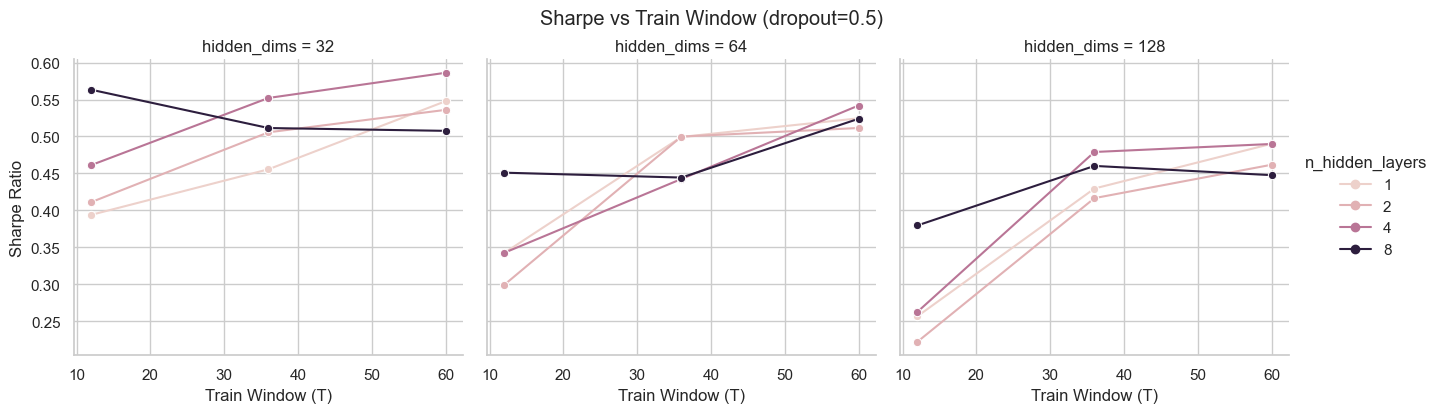

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = nn_results.copy()
df["n_hidden_layers"] = df["num_hidden_layers"]  # Ensure consistent naming
# Normalize expected column names
if "SR" in df.columns:
    metric = "SR"
elif "Sharpe" in df.columns:
    metric = "Sharpe"
else:
    raise ValueError("Could not find Sharpe column (expected 'SR' or 'Sharpe').")

# If you stored different names, map them here
rename_map = {}
if "T" in df.columns and "train_window" not in df.columns:
    rename_map["T"] = "train_window"
if "n_layers" in df.columns and "n_hidden_layers" not in df.columns:
    rename_map["n_layers"] = "n_hidden_layers"
if "dropout_rate" in df.columns and "dropout" not in df.columns:
    rename_map["dropout_rate"] = "dropout"
df = df.rename(columns=rename_map)

# Keep only dropout = 0.5
if "dropout" in df.columns:
    df = df[df["dropout"] == 0.5].copy()
else:
    print("No dropout column found; assuming all rows are dropout=0.5")

# Ensure numeric typing
for c in ["train_window", "n_hidden_layers", "hidden_dims"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[metric, "train_window", "n_hidden_layers", "hidden_dims"])
df = df.sort_values(["hidden_dims", "n_hidden_layers", "train_window"])
# 1) Curves: Sharpe vs Train Window, one line per #layers, faceted by hidden_dims
g = sns.relplot(
    data=df,
    x="train_window",
    y=metric,
    hue="n_hidden_layers",
    style="n_hidden_layers",
    col="hidden_dims",
    kind="line",
    marker="o",
    dashes=False,
    facet_kws={"sharey": True, "sharex": True},
    height=4,
    aspect=1.1,
)
g.set_axis_labels("Train Window (T)", "Sharpe Ratio")
g.set_titles("hidden_dims = {col_name}")
g.fig.suptitle("Sharpe vs Train Window (dropout=0.5)", y=1.03)
plt.show()



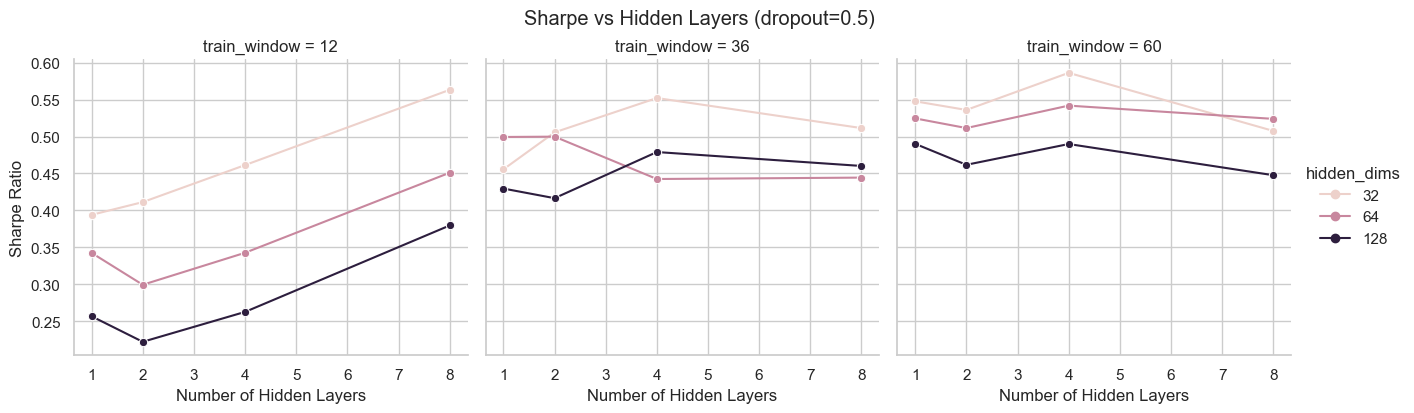

In [ ]:
# 2) Curves: Sharpe vs #Hidden Layers, one line per hidden_dims, faceted by train_window
g = sns.relplot(
    data=df,
    x="n_hidden_layers",
    y=metric,
    hue="hidden_dims",
    style="hidden_dims",
    col="train_window",
    kind="line",
    marker="o",
    dashes=False,4
    facet_kws={"sharey": True, "sharex": True},
    height=4,
    aspect=1.1,
)
g.set_axis_labels("Number of Hidden Layers", "Sharpe Ratio")
g.set_titles("train_window = {col_name}")
g.fig.suptitle("Sharpe vs Hidden Layers (dropout=0.5)", y=1.03)
plt.show()


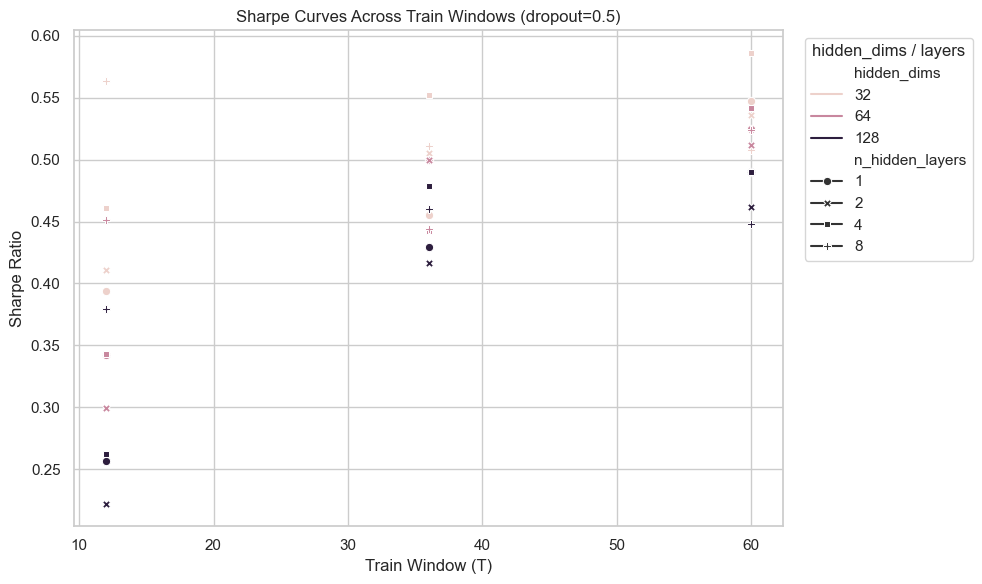

In [ ]:
# 3) Single combined curve plot (all values together)
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="train_window",
    y=metric,
    hue="hidden_dims",
    style="n_hidden_layers",
    markers=True,
    dashes=False,
    estimator=None,
    units=df.index,  # plot each run if duplicates exist
)
plt.title("Sharpe Curves Across Train Windows (dropout=0.5)")
plt.xlabel("Train Window (T)")
plt.ylabel("Sharpe Ratio")
plt.legend(title="hidden_dims / layers", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


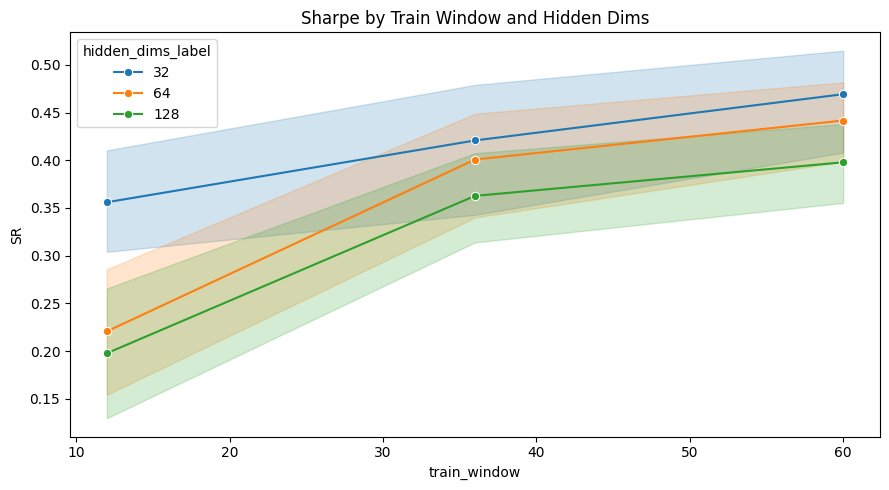

In [22]:
# 3) Sharpe vs train window (if multiple T values were run)
if nn["train_window"].nunique() > 1:
    plt.figure(figsize=(9,5))
    sns.lineplot(
        data=nn.sort_values("train_window"),
        x="train_window", y=sharpe_col,
        hue="hidden_dims_label", marker="o"
    )
    plt.title("Sharpe by Train Window and Hidden Dims")
    plt.tight_layout()
    plt.show()


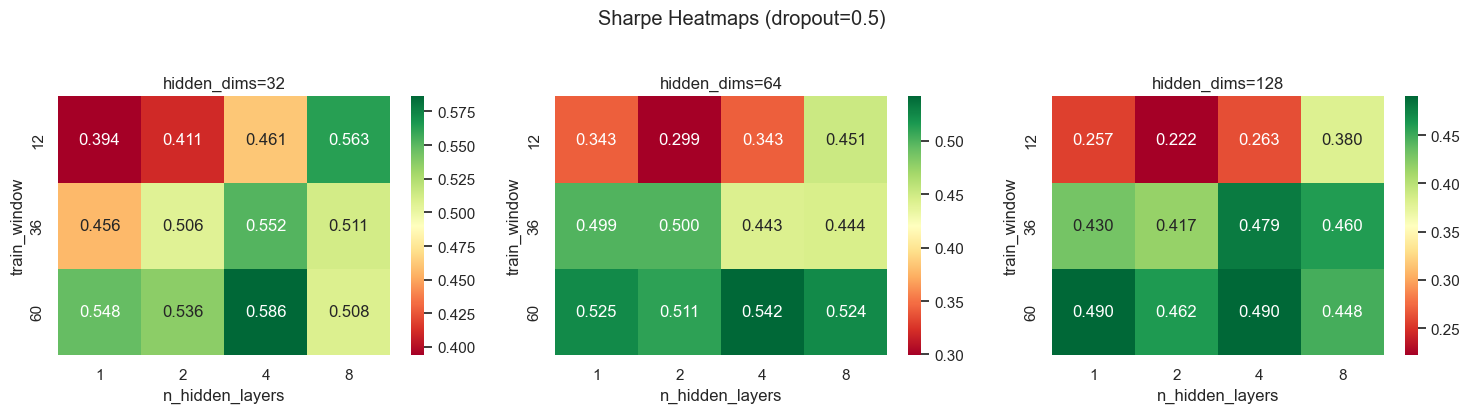

In [33]:
# 4) Heatmap: Sharpe by train_window x n_hidden_layers (one panel per hidden_dims)
hidden_vals = sorted(df["hidden_dims"].dropna().unique())
fig, axes = plt.subplots(1, len(hidden_vals), figsize=(5*len(hidden_vals), 4), squeeze=False)

for i, h in enumerate(hidden_vals):
    ax = axes[0, i]
    d = df[df["hidden_dims"] == h]
    p = d.pivot_table(index="train_window", columns="n_hidden_layers", values=metric, aggfunc="mean")
    sns.heatmap(p, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax)
    ax.set_title(f"hidden_dims={int(h)}")
    ax.set_xlabel("n_hidden_layers")
    ax.set_ylabel("train_window")
plt.suptitle("Sharpe Heatmaps (dropout=0.5)", y=1.03)
plt.tight_layout()
plt.show()


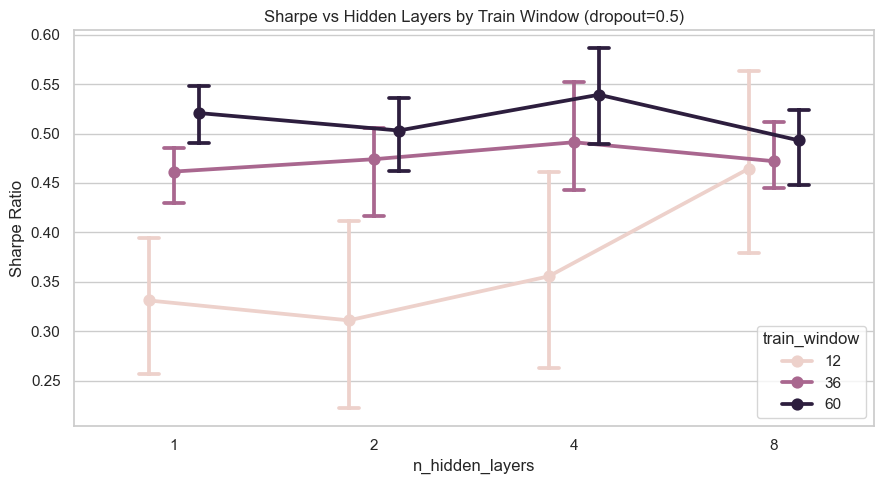

In [34]:
# 5) Point plot with uncertainty bars: compare layer effect at each train window
plt.figure(figsize=(9, 5))
sns.pointplot(
    data=df,
    x="n_hidden_layers",
    y=metric,
    hue="train_window",
    dodge=0.25,
    errorbar=("ci", 95),
    capsize=0.1
)
plt.title("Sharpe vs Hidden Layers by Train Window (dropout=0.5)")
plt.xlabel("n_hidden_layers")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()


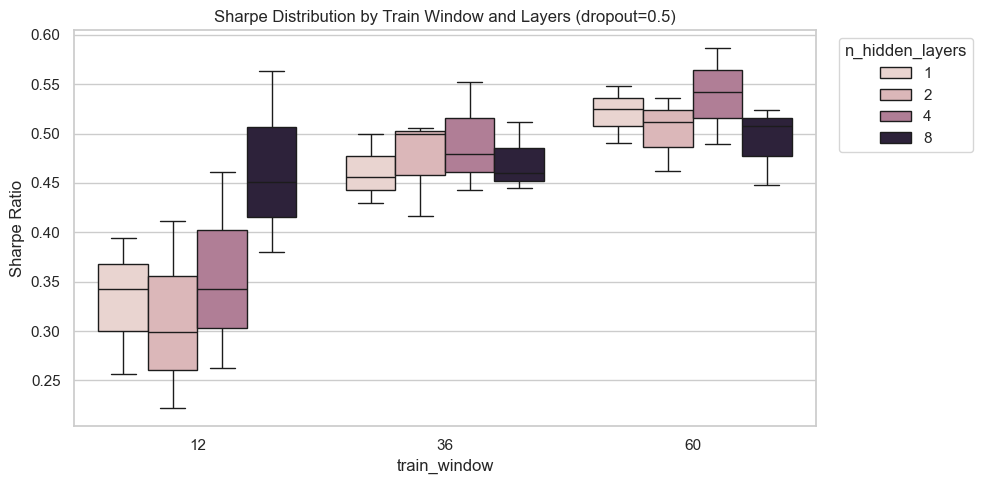

In [35]:
# 6) Boxplot: distribution across repeated runs (if you reran configs multiple times)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="train_window", y=metric, hue="n_hidden_layers")
plt.title("Sharpe Distribution by Train Window and Layers (dropout=0.5)")
plt.xlabel("train_window")
plt.ylabel("Sharpe Ratio")
plt.legend(title="n_hidden_layers", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


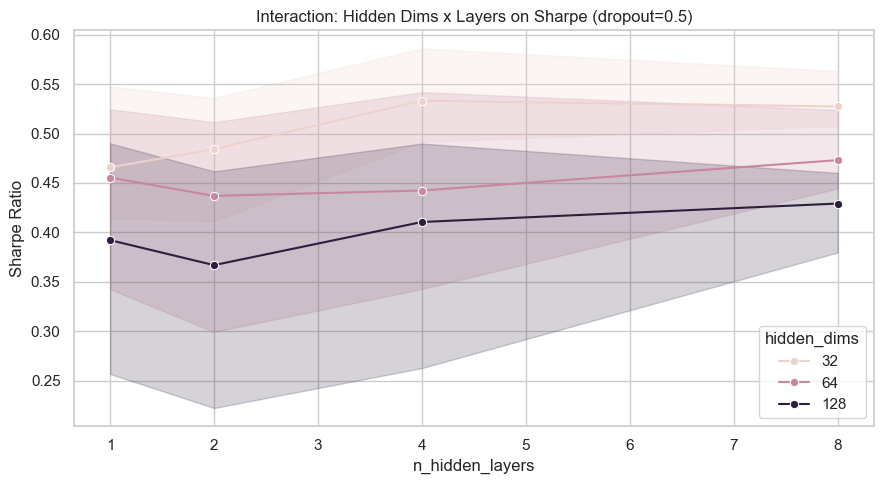

In [36]:
# 7) Interaction plot: show whether layer-depth effect changes with hidden_dims
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df,
    x="n_hidden_layers",
    y=metric,
    hue="hidden_dims",
    marker="o",
    errorbar=("ci", 95)
)
plt.title("Interaction: Hidden Dims x Layers on Sharpe (dropout=0.5)")
plt.xlabel("n_hidden_layers")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()


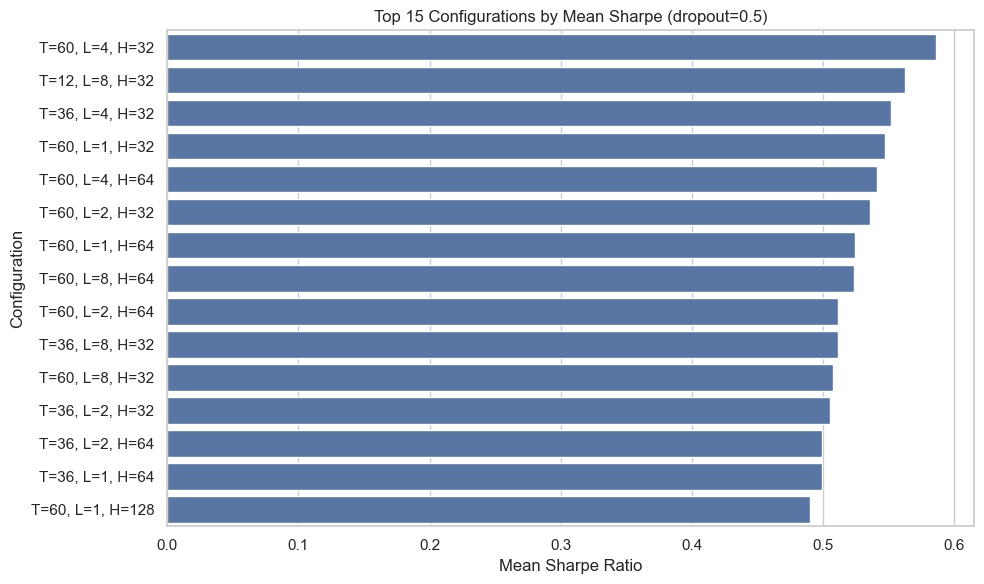

In [37]:
# 8) Rank plot of best configurations
rank_cols = ["train_window", "n_hidden_layers", "hidden_dims"]
top = (
    df.groupby(rank_cols, as_index=False)[metric].mean()
      .sort_values(metric, ascending=False)
      .head(15)
      .reset_index(drop=True)
)
top["config"] = top.apply(
    lambda r: f"T={int(r.train_window)}, L={int(r.n_hidden_layers)}, H={int(r.hidden_dims)}", axis=1
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top, y="config", x=metric, orient="h")
plt.title("Top 15 Configurations by Mean Sharpe (dropout=0.5)")
plt.xlabel("Mean Sharpe Ratio")
plt.ylabel("Configuration")
plt.tight_layout()
plt.show()
